In [162]:
import pandas as pd
import geopandas as gpd

In [163]:
data_path = "../One_Acre_Fund_MEL_maize_survey_data_2016-2022.csv"

In [164]:
df = pd.read_csv(data_path)

In [165]:
print(df.head(5))

   year     lon    lat         strat  avg_season_gdd  avg_season_ai  \
0  2016  34.067  0.227  01_KEN7701S1     2509.099854       0.998492   
1  2017  34.100  0.240  01_KEN7701S1     2552.900146       1.038017   
2  2019  34.082  0.247  01_KEN7701S1     2580.099854       1.008526   
3  2020  34.098  0.232  01_KEN7701S1     2562.800049       1.018445   
4  2020  34.094  0.274  01_KEN7701S1     2612.800049       1.023641   

   avg_season_tavg  season_prec  season_prec_1  season_prec_2  season_prec_3  \
0        21.275661   677.039708     228.759519     365.227443      83.052746   
1        21.507408   760.532583     154.624451     464.134379     141.773752   
2        21.651323   724.153837     181.676820     359.354439     183.122578   
3        21.559790   998.342599     379.451999     428.776234     190.114366   
4        21.824339   998.342599     379.451999     428.776234     190.114366   

   elev        twi  soil_rzpawhc  soil_clay  soil_pH  soil_orgC  soil_ECEC  \
0  1280   8.32

In [166]:
geometry = gpd.points_from_xy(df['lon'], df['lat'])
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")


In [167]:
print(gdf.tail(5))

       year     lon     lat strat  avg_season_gdd  avg_season_ai  \
14768  2018  29.111 -13.936   NaN     1756.599976       1.315969   
14769  2018  29.110 -13.943   NaN     1768.600098       1.312766   
14770  2018  29.104 -13.947   NaN     1759.500000       1.321671   
14771  2019  29.077 -13.927   NaN     1744.599976       1.340801   
14772  2018  29.131 -13.931   NaN     1780.599976       1.315773   

       avg_season_tavg  season_prec  season_prec_1  season_prec_2  \
14768        22.638334  1031.990413     360.000070     565.835843   
14769        22.738335  1031.990413     360.000070     565.835843   
14770        22.662500  1031.990413     360.000070     565.835843   
14771        22.538334   754.397238     276.229757     358.046937   
14772        22.838333  1055.542996     378.859419     569.843782   

       season_prec_3  elev        twi  soil_rzpawhc  soil_clay  soil_pH  \
14768     106.154500  1174  10.153633    109.599998       19.0      5.9   
14769     106.154500  1171

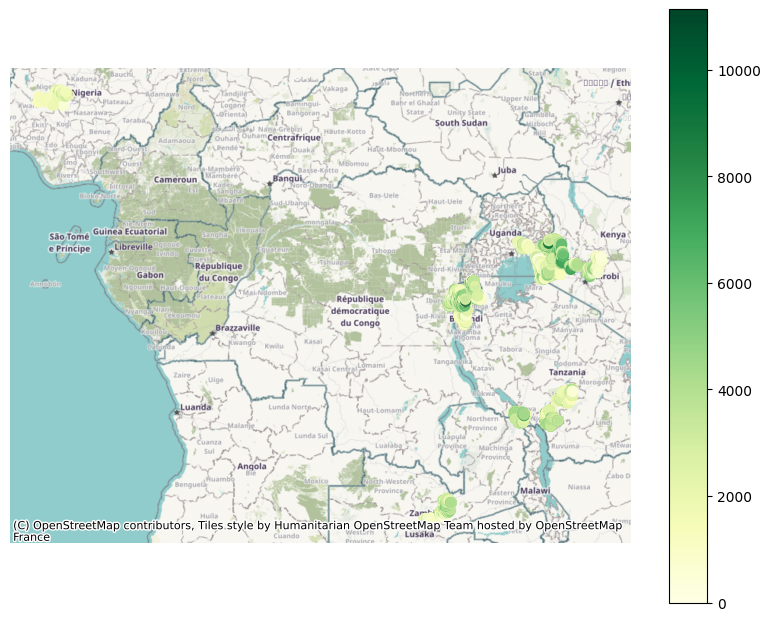

In [168]:
import contextily as ctx
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# Plot your data (ensure it's reprojected to Web Mercator)
gdf.to_crs(epsg=3857).plot(
    ax=ax, 
    column='yield_kg_ha', 
    cmap='YlGn', 
    legend=True, 
    markersize=50, 
    alpha=0.7
)

# Use CartoDB Light basemap
ctx.add_basemap(ax=ax, source=ctx.providers.OpenStreetMap.HOT)

ax.set_axis_off()
plt.show()


In [169]:
gdf.columns


Index(['year', 'lon', 'lat', 'strat', 'avg_season_gdd', 'avg_season_ai',
       'avg_season_tavg', 'season_prec', 'season_prec_1', 'season_prec_2',
       'season_prec_3', 'elev', 'twi', 'soil_rzpawhc', 'soil_clay', 'soil_pH',
       'soil_orgC', 'soil_ECEC', 'yield_kg_ha', 'geometry'],
      dtype='str')

In [170]:
gdf_kenya = gdf[gdf['strat'].str.contains('KEN')]

gdf_kenya.head()

,year,lon,lat,strat,avg_season_gdd,avg_season_ai,avg_season_tavg,season_prec,season_prec_1,season_prec_2,season_prec_3,elev,twi,soil_rzpawhc,soil_clay,soil_pH,soil_orgC,soil_ECEC,yield_kg_ha,geometry
0,2016,34.067,0.227,01_KEN7701S1,2509.099854,0.998492,21.275661,677.039708,228.759519,365.227443,83.052746,1280,8.322142,120.0,34.0,6.3,11.182494,13.879732,1462.951369,POINT (34.067 0.227)
1,2017,34.100,0.240,01_KEN7701S1,2552.900146,1.038017,21.507408,760.532583,154.624451,464.134379,141.773752,1288,10.117007,120.0,38.0,5.9,12.463738,12.463738,2817.771269,POINT (34.1 0.24)
2,2019,34.082,0.247,01_KEN7701S1,2580.099854,1.008526,21.651323,724.153837,181.676820,359.354439,183.122578,1243,7.909871,120.0,33.0,6.2,10.023176,10.023176,0.000000,POINT (34.082 0.247)
3,2020,34.098,0.232,01_KEN7701S1,2562.800049,1.018445,21.559790,998.342599,379.451999,428.776234,190.114366,1271,8.969049,120.0,32.0,6.0,10.023176,10.023176,4788.722787,POINT (34.098 0.232)
4,2020,34.094,0.274,01_KEN7701S1,2612.800049,1.023641,21.824339,998.342599,379.451999,428.776234,190.114366,1226,6.008638,120.0,33.0,5.9,12.463738,11.182494,2193.982268,POINT (34.094 0.274)


In [171]:
gdf_kenya.duplicated().sum()

np.int64(2)

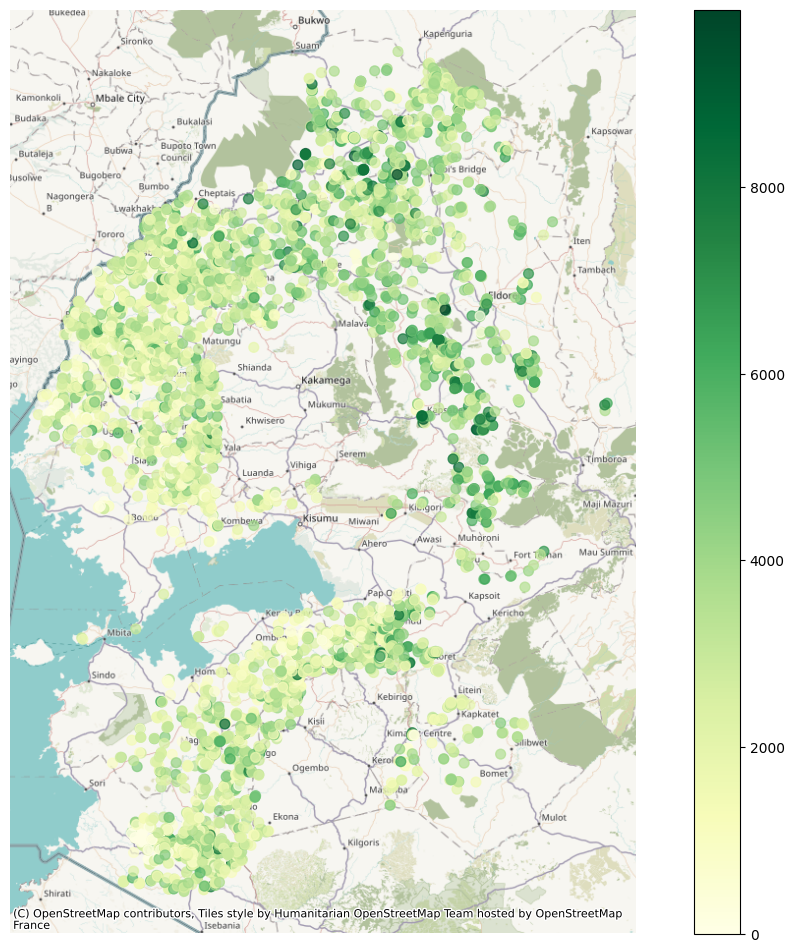

In [172]:

fig, ax = plt.subplots(figsize=(15, 12))

# Plot your data (ensure it's reprojected to Web Mercator)
gdf_kenya.to_crs(epsg=3857).plot(
    ax=ax, 
    column='yield_kg_ha', 
    cmap='YlGn', 
    legend=True, 
    markersize=50, 
    alpha=0.7
)

# Use CartoDB Light basemap
ctx.add_basemap(ax=ax, source=ctx.providers.OpenStreetMap.HOT)

ax.set_axis_off()
plt.show()


In [173]:
gdf_kenya.columns

Index(['year', 'lon', 'lat', 'strat', 'avg_season_gdd', 'avg_season_ai',
       'avg_season_tavg', 'season_prec', 'season_prec_1', 'season_prec_2',
       'season_prec_3', 'elev', 'twi', 'soil_rzpawhc', 'soil_clay', 'soil_pH',
       'soil_orgC', 'soil_ECEC', 'yield_kg_ha', 'geometry'],
      dtype='str')

In [174]:
gdf_kenya.head(1)

,year,lon,lat,strat,avg_season_gdd,avg_season_ai,avg_season_tavg,season_prec,season_prec_1,season_prec_2,season_prec_3,elev,twi,soil_rzpawhc,soil_clay,soil_pH,soil_orgC,soil_ECEC,yield_kg_ha,geometry
0,2016,34.067,0.227,01_KEN7701S1,2509.099854,0.998492,21.275661,677.039708,228.759519,365.227443,83.052746,1280,8.322142,120.0,34.0,6.3,11.182494,13.879732,1462.951369,POINT (34.067 0.227)


In [175]:
print(gdf_kenya.isnull().sum())
print(gdf_kenya.shape)

year                 0
lon                  0
lat                  0
strat                0
avg_season_gdd       0
avg_season_ai        0
avg_season_tavg      0
season_prec          0
season_prec_1        0
season_prec_2        0
season_prec_3        0
elev                 0
twi                  0
soil_rzpawhc       128
soil_clay          128
soil_pH            128
soil_orgC          128
soil_ECEC          128
yield_kg_ha          0
geometry             0
dtype: int64
(4841, 20)


In [176]:
gdf_kenya = gdf_kenya.dropna()
gdf_kenya.isnull().sum()
print(gdf_kenya.shape)

(4713, 20)


In [177]:
df_kenya = df[df['strat'].str.contains('KEN')]
print(f"Duplicate rows: {df_kenya.duplicated().sum()}")
print(f"Null values: {df_kenya.isnull().sum()}")
print(f"Shape: {df_kenya.shape}")

Duplicate rows: 2
Null values: year                 0
lon                  0
lat                  0
strat                0
avg_season_gdd       0
avg_season_ai        0
avg_season_tavg      0
season_prec          0
season_prec_1        0
season_prec_2        0
season_prec_3        0
elev                 0
twi                  0
soil_rzpawhc       128
soil_clay          128
soil_pH            128
soil_orgC          128
soil_ECEC          128
yield_kg_ha          0
dtype: int64
Shape: (4841, 19)


In [178]:
#dropping null values and duplicates
df_kenya = df_kenya.dropna().drop_duplicates().reset_index(drop=True)
print(f"Shape after cleaning: {df_kenya.shape}")

Shape after cleaning: (4713, 19)


In [179]:
#dropping columns that are not needed for analysis
df_kenya = df_kenya.drop(columns=['year','lon', 'lat', 'strat', 'season_prec_1', 'season_prec_2', 'season_prec_3'])
df_kenya.head()

,avg_season_gdd,avg_season_ai,avg_season_tavg,season_prec,elev,twi,soil_rzpawhc,soil_clay,soil_pH,soil_orgC,soil_ECEC,yield_kg_ha
0,2509.099854,0.998492,21.275661,677.039708,1280,8.322142,120.0,34.0,6.3,11.182494,13.879732,1462.951369
1,2552.900146,1.038017,21.507408,760.532583,1288,10.117007,120.0,38.0,5.9,12.463738,12.463738,2817.771269
2,2580.099854,1.008526,21.651323,724.153837,1243,7.909871,120.0,33.0,6.2,10.023176,10.023176,0.000000
3,2562.800049,1.018445,21.559790,998.342599,1271,8.969049,120.0,32.0,6.0,10.023176,10.023176,4788.722787
4,2612.800049,1.023641,21.824339,998.342599,1226,6.008638,120.0,33.0,5.9,12.463738,11.182494,2193.982268


In [180]:
# Remove rows with non-positive yields
print(df_kenya[df_kenya['yield_kg_ha'] <= 0].shape)

df_kenya = df_kenya[df_kenya['yield_kg_ha'] > 0].reset_index(drop=True)
print(f"Shape after removing non-positive yields: {df_kenya.shape}")

(78, 12)
Shape after removing non-positive yields: (4635, 12)


In [181]:
df_kenya.head(5)

,avg_season_gdd,avg_season_ai,avg_season_tavg,season_prec,elev,twi,soil_rzpawhc,soil_clay,soil_pH,soil_orgC,soil_ECEC,yield_kg_ha
0,2509.099854,0.998492,21.275661,677.039708,1280,8.322142,120.0,34.0,6.3,11.182494,13.879732,1462.951369
1,2552.900146,1.038017,21.507408,760.532583,1288,10.117007,120.0,38.0,5.9,12.463738,12.463738,2817.771269
2,2562.800049,1.018445,21.559790,998.342599,1271,8.969049,120.0,32.0,6.0,10.023176,10.023176,4788.722787
3,2612.800049,1.023641,21.824339,998.342599,1226,6.008638,120.0,33.0,5.9,12.463738,11.182494,2193.982268
4,2580.099854,1.109763,21.651323,806.058005,1264,6.048369,120.0,33.0,5.7,13.879732,12.463738,6227.084346


In [ ]:
# Copy your existing table
df = df_kenya.copy()

#df = df.dropna().drop_duplicates().reset_index(drop=True)
#df = df.drop(columns=['year','lon', 'lat', 'strat', 'season_prec_1', 'season_prec_2', 'season_prec_3'])
#df = df[df['yield_kg_ha'] > 0].reset_index(drop=True)

# Columns available in your table
target = "yield_kg_ha"

features = [
    "avg_season_gdd",
    "avg_season_ai",
    "avg_season_tavg",
    "season_prec",
    "elev",
    "twi",
    "soil_rzpawhc",
    "soil_clay",
    "soil_pH",
    "soil_orgC",
    "soil_ECEC",
]

print("\nYield summary:")
print(df[target].describe())


Yield summary:
count    4635.000000
mean     3039.297501
std      1663.161452
min         9.509521
25%      1838.866164
50%      2753.685606
75%      3966.828621
max      9903.543808
Name: yield_kg_ha, dtype: float64


In [187]:

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

models = {
    "Dummy baseline": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyRegressor(strategy="mean")),
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=500,
            min_samples_leaf=3,
            max_features=0.8,
            random_state=42,
            n_jobs=-1,
        )),
    ]),

    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=4,
            min_child_weight=5,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=2.0,
            objective="reg:squarederror",
            eval_metric="mae",
            random_state=42,
            n_jobs=-1,
        )),
    ]),

    "Hist Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingRegressor(
            max_iter=500,
            learning_rate=0.05,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=42,
        )),
    ]),
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE_kg_ha": mae,
        "RMSE_kg_ha": rmse,
        "R2": r2,
    })

    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values(
    "MAE_kg_ha"
)

print(results_df.to_string(index=False))

                 Model   MAE_kg_ha  RMSE_kg_ha        R2
         Random Forest 1105.090629 1428.361813  0.247887
               XGBoost 1116.546815 1438.429274  0.237247
Hist Gradient Boosting 1133.342484 1464.317382  0.209545
        Dummy baseline 1278.032844 1647.123371 -0.000136


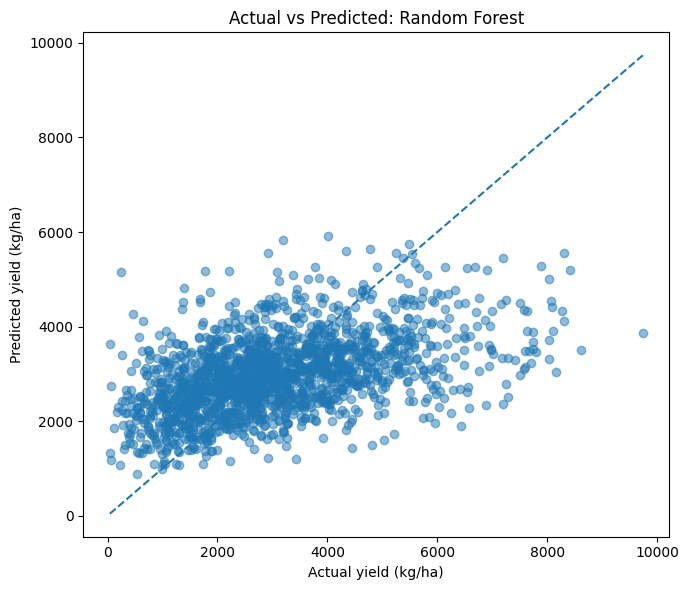

Selected model: Random Forest


In [184]:

import matplotlib.pyplot as plt

best_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_name]

y_pred = best_model.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

lower = min(y_test.min(), y_pred.min())
upper = max(y_test.max(), y_pred.max())

plt.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
)

plt.xlabel("Actual yield (kg/ha)")
plt.ylabel("Predicted yield (kg/ha)")
plt.title(f"Actual vs Predicted: {best_name}")
plt.tight_layout()
plt.show()

print("Selected model:", best_name)

elev               0.165806
season_prec        0.136735
avg_season_ai      0.135501
twi                0.119609
avg_season_gdd     0.100407
avg_season_tavg    0.090200
soil_clay          0.066379
soil_rzpawhc       0.056187
soil_pH            0.047156
soil_ECEC          0.045015
soil_orgC          0.037006
dtype: float64


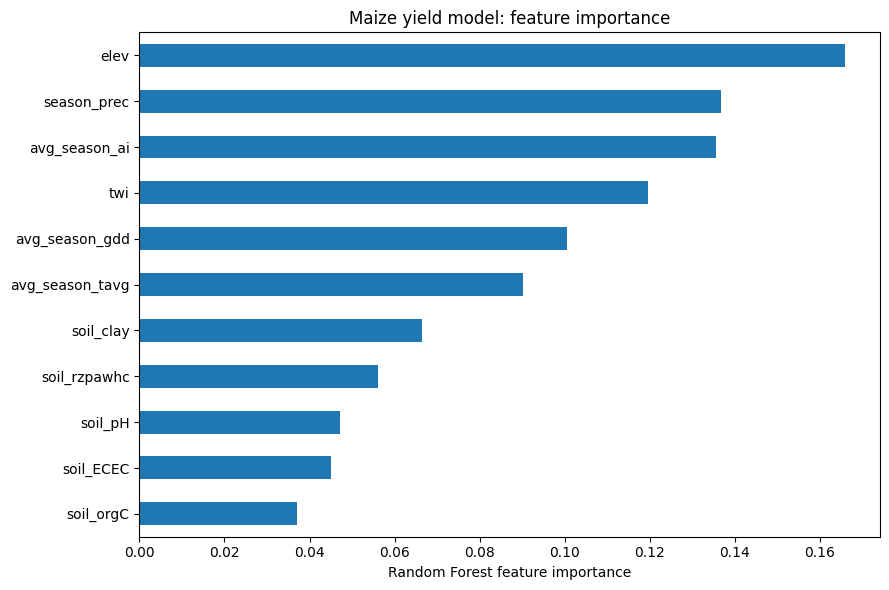

In [185]:
rf = trained_models["Random Forest"]
rf_model = rf.named_steps["model"]

importance = pd.Series(
    rf_model.feature_importances_,
    index=features,
).sort_values()

print(importance.sort_values(ascending=False))

importance.plot(
    kind="barh",
    figsize=(9, 6),
)
plt.xlabel("Random Forest feature importance")
plt.title("Maize yield model: feature importance")
plt.tight_layout()
plt.show()

Permutation importance (increase in MAE when shuffled):
elev               244.91
season_prec         87.71
avg_season_tavg     48.91
avg_season_gdd      25.07
soil_ECEC           11.18
avg_season_ai       10.68
soil_orgC           10.55
soil_rzpawhc         9.73
soil_pH              5.55
soil_clay            0.68
twi                 -0.22
dtype: float64


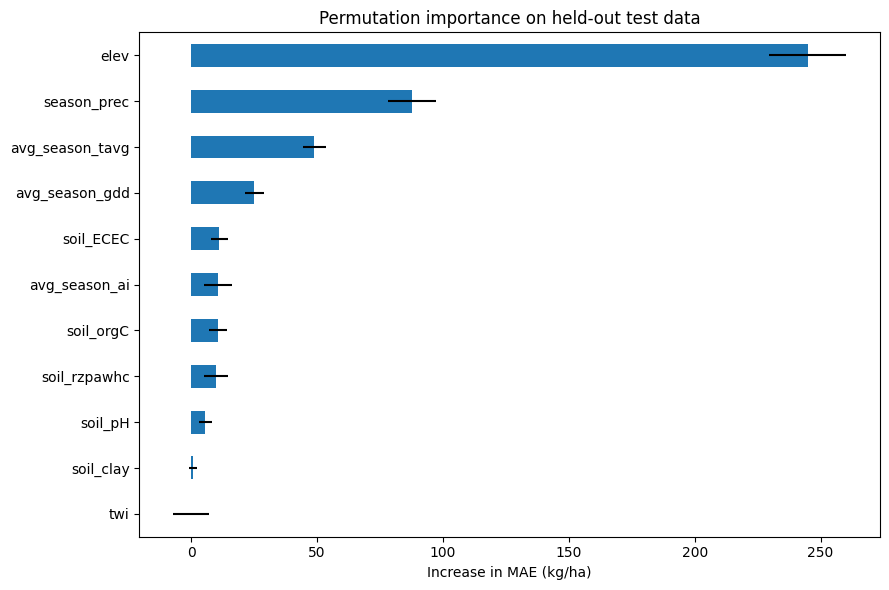

In [161]:

from sklearn.inspection import permutation_importance

rf = trained_models["Random Forest"]

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=features,
).sort_values()

print("Permutation importance (increase in MAE when shuffled):")
print(perm_importance.sort_values(ascending=False).round(2))

perm_importance.plot(
    kind="barh",
    figsize=(9, 6),
    xerr=perm.importances_std[
        perm_importance.index.map(
            lambda name: features.index(name)
        )
    ],
)

plt.xlabel("Increase in MAE (kg/ha)")
plt.title("Permutation importance on held-out test data")
plt.tight_layout()
plt.show()